In [12]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from collections import Counter

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
)

from sklearn.preprocessing import label_binarize

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [ ]:
from google.colab import drive
drive.mount('/content/mydrive')

Mounted at /content/mydrive


In [13]:
# ============================================================
# CONFIGURATION
# ============================================================

from google.colab import drive
drive.mount('/content/mydrive')

BASE_DIR = '/content/mydrive/MyDrive/NLP_Research_Project'

ID_COLUMN = 'id'
TEXT_COLUMN = 'text'
LABEL_COLUMN = 'label'

# ------------------------------------------------------------
# Existing directories created by friend's ML notebook
# ------------------------------------------------------------

SPLITS_DIR = os.path.join(BASE_DIR, 'data', 'splits')

MODEL_DIR = os.path.join(
    BASE_DIR,
    'results',
    'models',
    'classical_ml',
    'trained_models'
)

VECTORIZER_DIR = os.path.join(
    BASE_DIR,
    'results',
    'models',
    'classical_ml',
    'vectorizers'
)

PREDICTION_DIR = os.path.join(
    BASE_DIR,
    'results',
    'predictions'
)

METRICS_DIR = os.path.join(
    BASE_DIR,
    'results',
    'metrics'
)

FIGURE_DIR = os.path.join(
    BASE_DIR,
    'results',
    'figures',
    'classical_ml_evaluation'
)

# ------------------------------------------------------------
# New directory specifically for YOUR outputs
# ------------------------------------------------------------

EXPLAINABILITY_DIR = os.path.join(
    BASE_DIR,
    'results',
    'explainability',
    'classical_ml'
)

ERROR_DIR = os.path.join(
    BASE_DIR,
    'results',
    'error_analysis',
    'classical_ml'
)

ADVANCED_METRICS_DIR = os.path.join(
    BASE_DIR,
    'results',
    'advanced_metrics',
    'classical_ml'
)

for directory in [
    FIGURE_DIR,
    EXPLAINABILITY_DIR,
    ERROR_DIR,
    ADVANCED_METRICS_DIR
]:
    os.makedirs(directory, exist_ok=True)

# ------------------------------------------------------------
# Existing files
# ------------------------------------------------------------

TRAIN_PATH = os.path.join(SPLITS_DIR, 'train.csv')
VAL_PATH = os.path.join(SPLITS_DIR, 'validation.csv')
TEST_PATH = os.path.join(SPLITS_DIR, 'test.csv')

VAL_PRED_PATH = os.path.join(
    PREDICTION_DIR,
    'ml_predictions_validation.csv'
)

TEST_PRED_PATH = os.path.join(
    PREDICTION_DIR,
    'ml_predictions_test.csv'
)

METRICS_PATH = os.path.join(
    METRICS_DIR,
    'metrics_summary_classical_ml.csv'
)

print("Configuration loaded.")
print("BASE_DIR:", BASE_DIR)

Drive already mounted at /content/mydrive; to attempt to forcibly remount, call drive.mount("/content/mydrive", force_remount=True).
Configuration loaded.
BASE_DIR: /content/mydrive/MyDrive/NLP_Research_Project


In [14]:
# ============================================================
# VERIFY EXISTING ARTIFACTS
# ============================================================

required_files = {
    'Train split': TRAIN_PATH,
    'Validation split': VAL_PATH,
    'Test split': TEST_PATH,
    'Validation predictions': VAL_PRED_PATH,
    'Test predictions': TEST_PRED_PATH,
    'Metrics summary': METRICS_PATH,
}

print("Artifact verification:\n")

all_available = True

for name, path in required_files.items():
    exists = os.path.exists(path)

    status = "FOUND" if exists else "MISSING"

    print(f"{status:10s} | {name:25s} | {path}")

    if not exists:
        all_available = False

if not all_available:
    raise FileNotFoundError(
        "One or more required artifacts are missing. "
        "Check BASE_DIR and the previous ML notebook."
    )

print("\nAll required artifacts are available.")

Artifact verification:

FOUND      | Train split               | /content/mydrive/MyDrive/NLP_Research_Project/data/splits/train.csv
FOUND      | Validation split          | /content/mydrive/MyDrive/NLP_Research_Project/data/splits/validation.csv
FOUND      | Test split                | /content/mydrive/MyDrive/NLP_Research_Project/data/splits/test.csv
FOUND      | Validation predictions    | /content/mydrive/MyDrive/NLP_Research_Project/results/predictions/ml_predictions_validation.csv
FOUND      | Test predictions          | /content/mydrive/MyDrive/NLP_Research_Project/results/predictions/ml_predictions_test.csv
FOUND      | Metrics summary           | /content/mydrive/MyDrive/NLP_Research_Project/results/metrics/metrics_summary_classical_ml.csv

All required artifacts are available.


In [17]:
# ============================================================
# LOAD DATA AND EXISTING PREDICTIONS
# ============================================================

train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

val_predictions = pd.read_csv(VAL_PRED_PATH)
test_predictions = pd.read_csv(TEST_PRED_PATH)

metrics_summary = pd.read_csv(METRICS_PATH)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nExisting ML metrics:")
display(metrics_summary)

Train: (6425, 4)
Validation: (1377, 4)
Test: (1377, 4)

Existing ML metrics:


,feature_type,model,train_time_sec,val_predict_time_sec,test_predict_time_sec,val_accuracy,val_precision_macro,val_recall_macro,val_f1_macro,val_precision_weighted,val_recall_weighted,val_f1_weighted,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_precision_weighted,test_recall_weighted,test_f1_weighted
0,tfidf,linear_svm,0.593904,0.002131,0.001920,0.907771,0.757213,0.731025,0.737544,0.911300,0.907771,0.909121,0.896877,0.754245,0.677431,0.695597,0.905122,0.896877,0.899857
1,countvectorizer,xgboost,34.870842,0.103625,0.102565,0.912854,0.768353,0.704292,0.731613,0.907177,0.912854,0.908686,0.888163,0.687506,0.562008,0.604792,0.876897,0.888163,0.880845
2,countvectorizer,logistic_regression,16.305059,0.004572,0.004283,0.900508,0.683797,0.714266,0.696023,0.907882,0.900508,0.903366,0.886710,0.698695,0.745445,0.718011,0.899655,0.886710,0.891594
3,countvectorizer,linear_svm,2.201394,0.001613,0.001273,0.900508,0.706115,0.660767,0.680642,0.899172,0.900508,0.899452,0.896151,0.671705,0.648701,0.654570,0.895628,0.896151,0.895398
4,tfidf,xgboost,128.765147,0.094936,0.092610,0.900508,0.741322,0.594660,0.650216,0.891998,0.900508,0.894283,0.893972,0.753944,0.552499,0.615566,0.884794,0.893972,0.886588
5,tfidf,logistic_regression,4.369495,0.006386,0.010354,0.828613,0.547313,0.724748,0.611224,0.893541,0.828613,0.848936,0.824256,0.672769,0.798440,0.714559,0.891217,0.824256,0.846367
6,countvectorizer,random_forest,33.130615,0.316850,0.305087,0.858388,0.584318,0.366625,0.422164,0.837959,0.858388,0.824970,0.865650,0.544473,0.387170,0.425184,0.834463,0.865650,0.830730
7,countvectorizer,naive_bayes,0.011852,0.001481,0.001330,0.796659,0.369539,0.324175,0.317684,0.799848,0.796659,0.791472,0.809731,0.344866,0.334320,0.318661,0.806226,0.809731,0.803906
8,tfidf,random_forest,27.014101,0.314791,0.288093,0.834423,0.590555,0.264593,0.311664,0.819978,0.834423,0.785985,0.841685,0.547786,0.283899,0.336599,0.808933,0.841685,0.794768
9,tfidf,naive_bayes,0.010865,0.001431,0.001306,0.796659,0.171241,0.145137,0.131816,0.667944,0.796659,0.710055,0.796659,0.150063,0.145033,0.131829,0.658084,0.796659,0.711199


In [19]:
# ============================================================
# DATASET / MODEL INFORMATION
# ============================================================

classes = sorted(train_df[LABEL_COLUMN].unique())

models_available = sorted(
    test_predictions['model'].unique()
)

feature_types = sorted(
    test_predictions['feature_type'].unique()
)

print("BI-RADS classes:")
print(classes)

print("\nModels:")
print(models_available)

print("\nFeature types:")
print(feature_types)

BI-RADS classes:
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Models:
['linear_svm', 'logistic_regression', 'naive_bayes', 'random_forest', 'xgboost']

Feature types:
['countvectorizer', 'tfidf']


In [20]:
# ============================================================
# PREDICTION INTEGRITY CHECK
# ============================================================

print("Checking prediction integrity...\n")

expected_test_rows = len(test_df)

for feature_type in feature_types:
    for model_name in models_available:

        subset = test_predictions[
            (test_predictions['feature_type'] == feature_type) &
            (test_predictions['model'] == model_name)
        ]

        print(
            f"{feature_type:18s} | "
            f"{model_name:22s} | "
            f"rows = {len(subset)}"
        )

        assert len(subset) == expected_test_rows, (
            f"Prediction row mismatch for {feature_type} + {model_name}"
        )

print("\nPrediction integrity check passed.")

Checking prediction integrity...

countvectorizer    | linear_svm             | rows = 1377
countvectorizer    | logistic_regression    | rows = 1377
countvectorizer    | naive_bayes            | rows = 1377
countvectorizer    | random_forest          | rows = 1377
countvectorizer    | xgboost                | rows = 1377
tfidf              | linear_svm             | rows = 1377
tfidf              | logistic_regression    | rows = 1377
tfidf              | naive_bayes            | rows = 1377
tfidf              | random_forest          | rows = 1377
tfidf              | xgboost                | rows = 1377

Prediction integrity check passed.


In [21]:
# ============================================================
# EXISTING PERFORMANCE RESULTS
# ============================================================

display(
    metrics_summary[
        [
            'feature_type',
            'model',
            'test_accuracy',
            'test_precision_macro',
            'test_recall_macro',
            'test_f1_macro',
            'test_f1_weighted'
        ]
    ].sort_values(
        'test_f1_macro',
        ascending=False
    )
)

,feature_type,model,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted
2,countvectorizer,logistic_regression,0.886710,0.698695,0.745445,0.718011,0.891594
5,tfidf,logistic_regression,0.824256,0.672769,0.798440,0.714559,0.846367
0,tfidf,linear_svm,0.896877,0.754245,0.677431,0.695597,0.899857
3,countvectorizer,linear_svm,0.896151,0.671705,0.648701,0.654570,0.895398
4,tfidf,xgboost,0.893972,0.753944,0.552499,0.615566,0.886588
1,countvectorizer,xgboost,0.888163,0.687506,0.562008,0.604792,0.880845
6,countvectorizer,random_forest,0.865650,0.544473,0.387170,0.425184,0.830730
8,tfidf,random_forest,0.841685,0.547786,0.283899,0.336599,0.794768
7,countvectorizer,naive_bayes,0.809731,0.344866,0.334320,0.318661,0.803906
9,tfidf,naive_bayes,0.796659,0.150063,0.145033,0.131829,0.711199


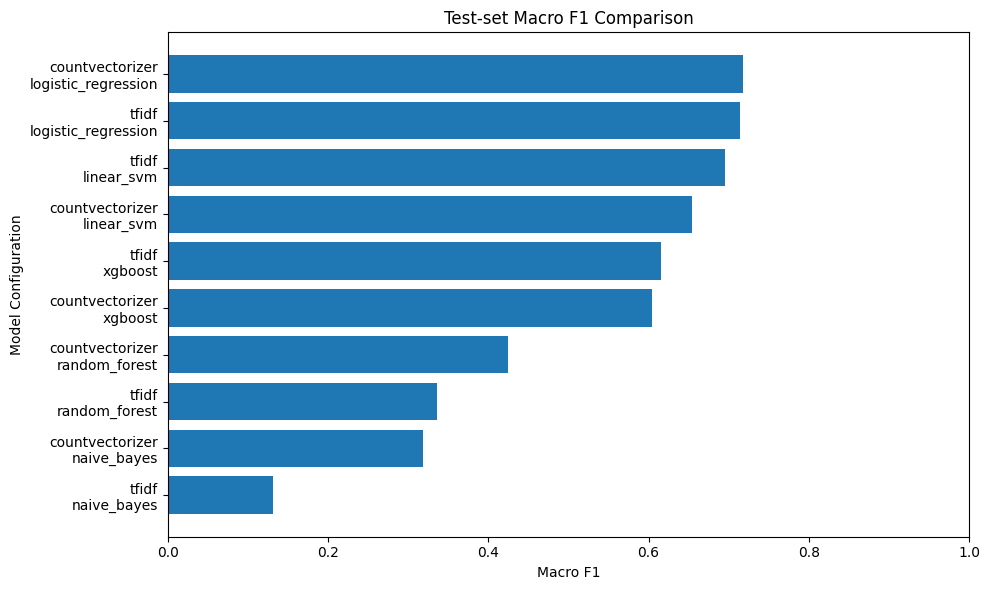

In [22]:
# ============================================================
# TEST MACRO-F1 COMPARISON
# ============================================================

plot_df = metrics_summary.copy()

plot_df['configuration'] = (
    plot_df['feature_type'] + '\n' + plot_df['model']
)

plot_df = plot_df.sort_values(
    'test_f1_macro',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    plot_df['configuration'],
    plot_df['test_f1_macro']
)

plt.xlabel('Macro F1')
plt.ylabel('Model Configuration')
plt.title('Test-set Macro F1 Comparison')

plt.xlim(0, 1)
plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        'test_macro_f1_comparison.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [23]:
# ============================================================
# BEST MODEL — SELECTED FROM VALIDATION PERFORMANCE
# ============================================================

best_row = metrics_summary.sort_values(
    'val_f1_macro',
    ascending=False
).iloc[0]

BEST_FEATURE_TYPE = best_row['feature_type']
BEST_MODEL_NAME = best_row['model']

print("Best configuration selected using validation Macro-F1:")
print("Feature type:", BEST_FEATURE_TYPE)
print("Model:", BEST_MODEL_NAME)
print("Validation Macro-F1:", round(best_row['val_f1_macro'], 4))

print("\nFinal test performance:")
print("Test Macro-F1:", round(best_row['test_f1_macro'], 4))
print("Test Accuracy:", round(best_row['test_accuracy'], 4))

Best configuration selected using validation Macro-F1:
Feature type: tfidf
Model: linear_svm
Validation Macro-F1: 0.7375

Final test performance:
Test Macro-F1: 0.6956
Test Accuracy: 0.8969


In [24]:
# ============================================================
# PER-CLASS TEST METRICS
# ============================================================

best_test_predictions = test_predictions[
    (test_predictions['feature_type'] == BEST_FEATURE_TYPE) &
    (test_predictions['model'] == BEST_MODEL_NAME)
].copy()

y_true = best_test_predictions['true_label']
y_pred = best_test_predictions['predicted_label']

report_dict = classification_report(
    y_true,
    y_pred,
    labels=classes,
    output_dict=True,
    zero_division=0
)

per_class_rows = []

for label in classes:

    row = report_dict[str(label)]

    per_class_rows.append({
        'class': label,
        'precision': row['precision'],
        'recall': row['recall'],
        'f1_score': row['f1-score'],
        'support': row['support']
    })

per_class_metrics = pd.DataFrame(per_class_rows)

display(per_class_metrics)

per_class_metrics.to_csv(
    os.path.join(
        ADVANCED_METRICS_DIR,
        'best_ml_per_class_test_metrics.csv'
    ),
    index=False
)

,class,precision,recall,f1_score,support
0,0,0.716981,0.835165,0.771574,91.0
1,1,0.888889,0.842105,0.864865,38.0
2,2,0.969216,0.945405,0.957163,1099.0
3,3,0.516393,0.594340,0.552632,106.0
4,4,0.588235,0.625000,0.606061,32.0
5,5,1.000000,0.400000,0.571429,5.0
6,6,0.600000,0.500000,0.545455,6.0


In [25]:
# ============================================================
# PER-CLASS TEST METRICS
# ============================================================

best_test_predictions = test_predictions[
    (test_predictions['feature_type'] == BEST_FEATURE_TYPE) &
    (test_predictions['model'] == BEST_MODEL_NAME)
].copy()

y_true = best_test_predictions['true_label']
y_pred = best_test_predictions['predicted_label']

report_dict = classification_report(
    y_true,
    y_pred,
    labels=classes,
    output_dict=True,
    zero_division=0
)

per_class_rows = []

for label in classes:

    row = report_dict[str(label)]

    per_class_rows.append({
        'class': label,
        'precision': row['precision'],
        'recall': row['recall'],
        'f1_score': row['f1-score'],
        'support': row['support']
    })

per_class_metrics = pd.DataFrame(per_class_rows)

display(per_class_metrics)

per_class_metrics.to_csv(
    os.path.join(
        ADVANCED_METRICS_DIR,
        'best_ml_per_class_test_metrics.csv'
    ),
    index=False
)

,class,precision,recall,f1_score,support
0,0,0.716981,0.835165,0.771574,91.0
1,1,0.888889,0.842105,0.864865,38.0
2,2,0.969216,0.945405,0.957163,1099.0
3,3,0.516393,0.594340,0.552632,106.0
4,4,0.588235,0.625000,0.606061,32.0
5,5,1.000000,0.400000,0.571429,5.0
6,6,0.600000,0.500000,0.545455,6.0


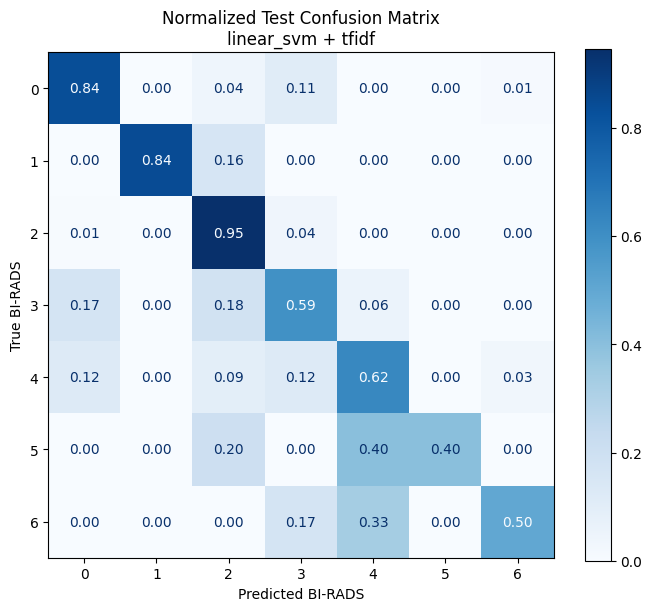

In [26]:
# ============================================================
# NORMALIZED TEST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=classes,
    normalize='true'
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    cmap='Blues',
    values_format='.2f',
    colorbar=True
)

ax.set_title(
    f'Normalized Test Confusion Matrix\n'
    f'{BEST_MODEL_NAME} + {BEST_FEATURE_TYPE}'
)

ax.set_xlabel('Predicted BI-RADS')
ax.set_ylabel('True BI-RADS')

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        'best_model_normalized_test_confusion_matrix.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [27]:
# ============================================================
# MISCLASSIFICATION ANALYSIS
# ============================================================

error_df = best_test_predictions[
    best_test_predictions['true_label'] !=
    best_test_predictions['predicted_label']
].copy()

print("Total test samples:", len(best_test_predictions))
print("Misclassified samples:", len(error_df))
print(
    "Error rate:",
    round(len(error_df) / len(best_test_predictions), 4)
)

display(error_df.head())

Total test samples: 1377
Misclassified samples: 142
Error rate: 0.1031


,id,true_label,predicted_label,feature_type,model
9650,Acc3875,3,4,tfidf,linear_svm
9651,Acc1897,6,4,tfidf,linear_svm
9654,Acc7222,6,4,tfidf,linear_svm
9684,Acc16984,0,2,tfidf,linear_svm
9686,Acc21538,2,4,tfidf,linear_svm


In [28]:
# ============================================================
# MOST COMMON MISCLASSIFICATION PAIRS
# ============================================================

misclassification_pairs = (
    error_df
    .groupby(
        ['true_label', 'predicted_label']
    )
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
)

display(misclassification_pairs)

misclassification_pairs.to_csv(
    os.path.join(
        ERROR_DIR,
        'misclassification_pairs.csv'
    ),
    index=False
)

,true_label,predicted_label,count
6,2,3,44
9,3,2,19
8,3,0,18
1,0,3,10
4,2,0,8
10,3,4,6
3,1,2,6
11,4,0,4
0,0,2,4
5,2,1,4


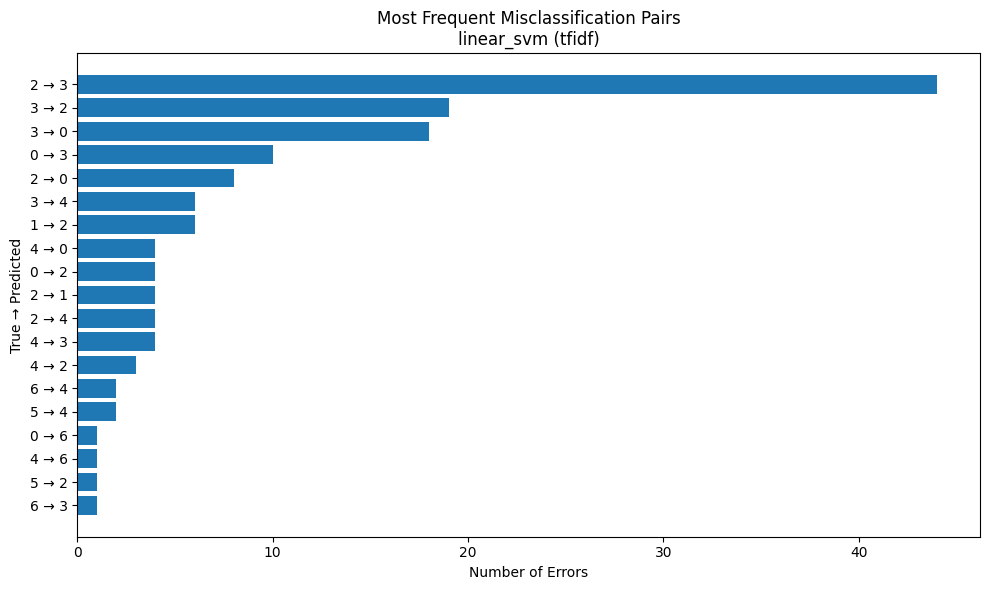

In [29]:
# ============================================================
# MISCLASSIFICATION PAIR VISUALIZATION
# ============================================================

pair_labels = (
    misclassification_pairs['true_label'].astype(str)
    + ' → '
    + misclassification_pairs['predicted_label'].astype(str)
)

plt.figure(figsize=(10, 6))

plt.barh(
    pair_labels[::-1],
    misclassification_pairs['count'][::-1]
)

plt.xlabel('Number of Errors')
plt.ylabel('True → Predicted')
plt.title(
    f'Most Frequent Misclassification Pairs\n'
    f'{BEST_MODEL_NAME} ({BEST_FEATURE_TYPE})'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        'misclassification_pairs.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [30]:
# ============================================================
# ERROR ANALYSIS WITH ORIGINAL TEXT
# ============================================================

error_with_text = error_df.merge(
    test_df[[ID_COLUMN, TEXT_COLUMN]],
    on=ID_COLUMN,
    how='left'
)

error_with_text = error_with_text[
    [
        ID_COLUMN,
        TEXT_COLUMN,
        'true_label',
        'predicted_label',
        'feature_type',
        'model'
    ]
]

display(error_with_text.head(20))

error_with_text.to_csv(
    os.path.join(
        ERROR_DIR,
        'misclassified_test_samples_with_text.csv'
    ),
    index=False
)

,id,text,true_label,predicted_label,feature_type,model
0,Acc3875,clinical indication tracking. findings partial...,3,4,tfidf,linear_svm
1,Acc1897,clinical indication tracking. findings dense b...,6,4,tfidf,linear_svm
2,Acc7222,clinical indication tracking. findings dense b...,6,4,tfidf,linear_svm
3,Acc16984,clinical indication tracking. she reports that...,0,2,tfidf,linear_svm
4,Acc21538,clinical indication tracking. findings breasts...,2,4,tfidf,linear_svm
5,Acc1540,clinical indication tracking. findings partial...,0,3,tfidf,linear_svm
6,Acc2939,clinical indication reassessment of changes ob...,3,4,tfidf,linear_svm
7,Acc5339,joint reports of mammographs from and clinical...,2,3,tfidf,linear_svm
8,Acc15428,clinical indication tracking. findings breasts...,2,3,tfidf,linear_svm
9,Acc3175,clinical indication trackingfindings dense bre...,3,0,tfidf,linear_svm


In [31]:
# ============================================================
# WORD CLOUD
# ============================================================

try:
    from wordcloud import WordCloud
except ImportError:
    !pip -q install wordcloud
    from wordcloud import WordCloud

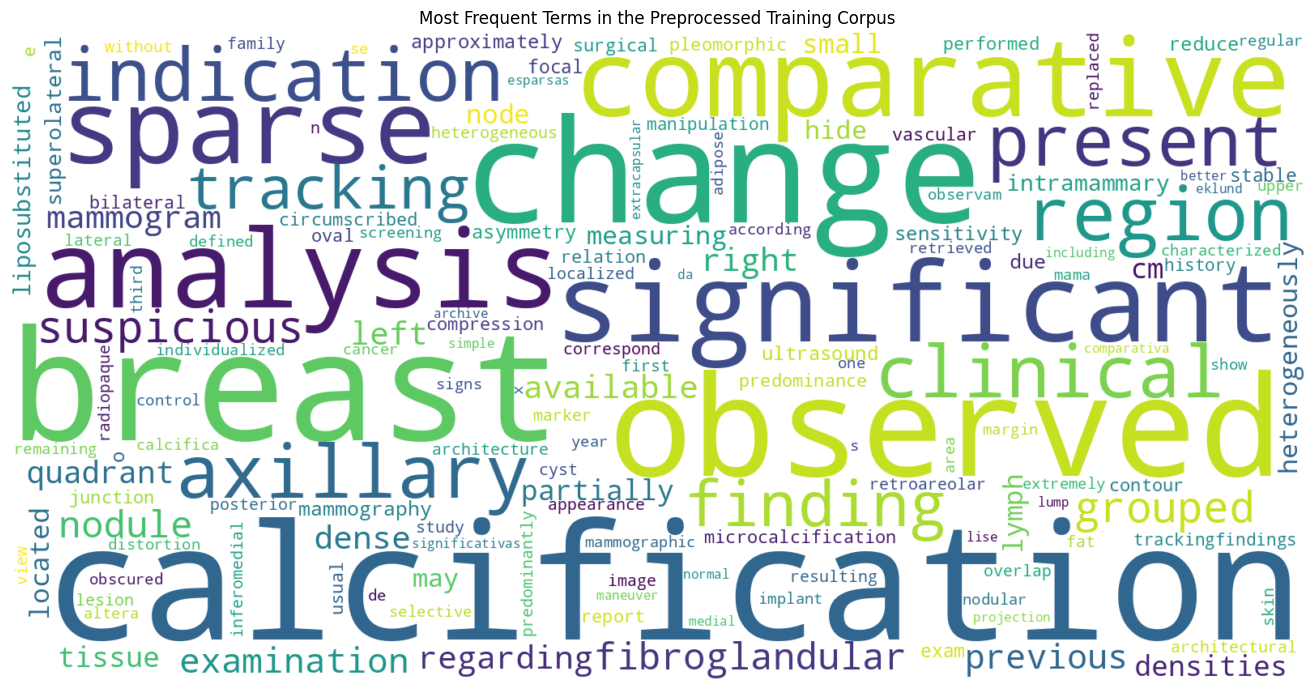

In [32]:
# ============================================================
# OVERALL WORD CLOUD
# ============================================================

all_text = ' '.join(
    train_df[TEXT_COLUMN]
    .fillna('')
    .astype(str)
)

wordcloud = WordCloud(
    width=1600,
    height=800,
    background_color='white',
    max_words=150,
    collocations=False
).generate(all_text)

plt.figure(figsize=(14, 7))

plt.imshow(
    wordcloud,
    interpolation='bilinear'
)

plt.axis('off')

plt.title(
    'Most Frequent Terms in the Preprocessed Training Corpus'
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        FIGURE_DIR,
        'overall_wordcloud.png'
    ),
    dpi=300,
    bbox_inches='tight'
)

plt.show()

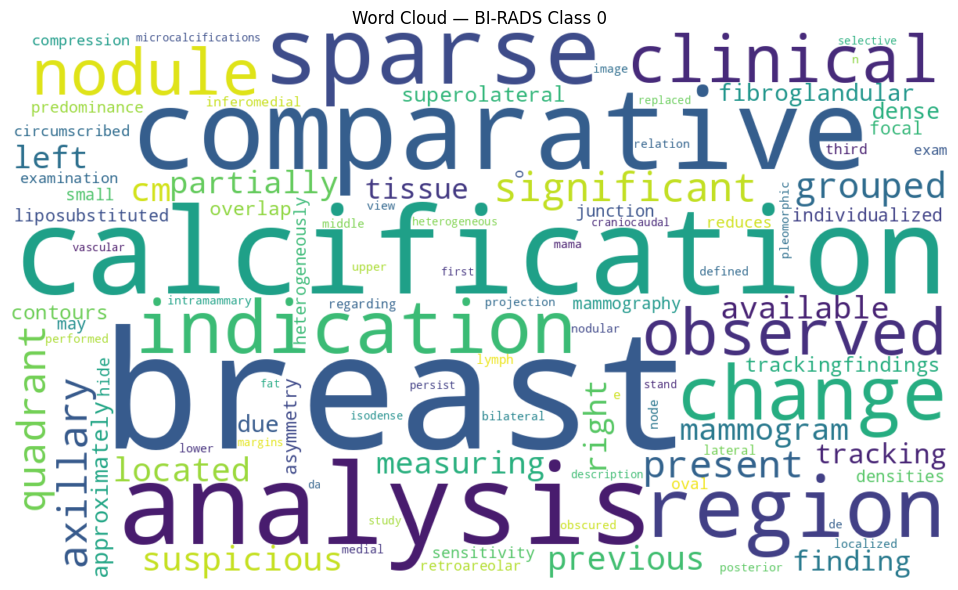

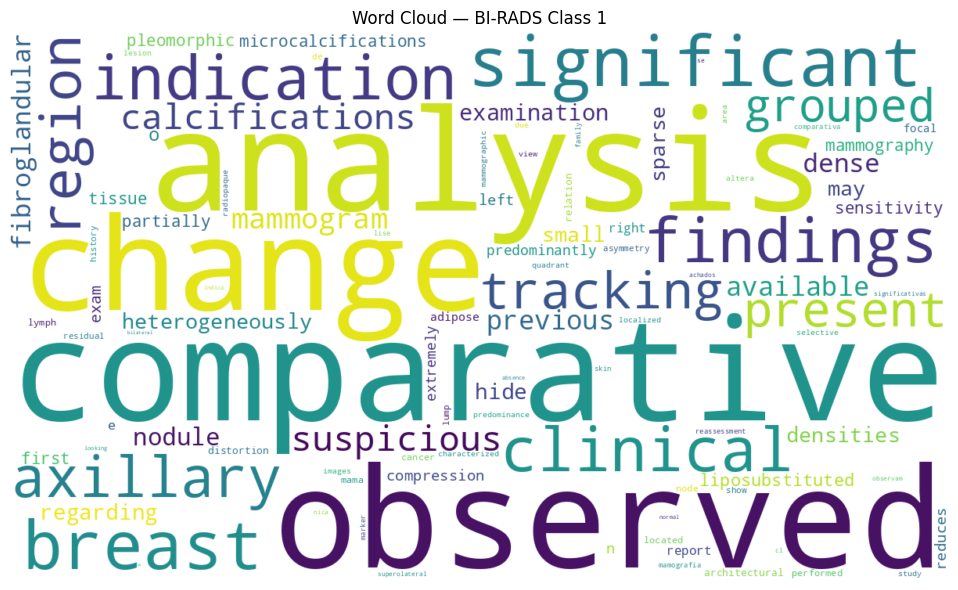

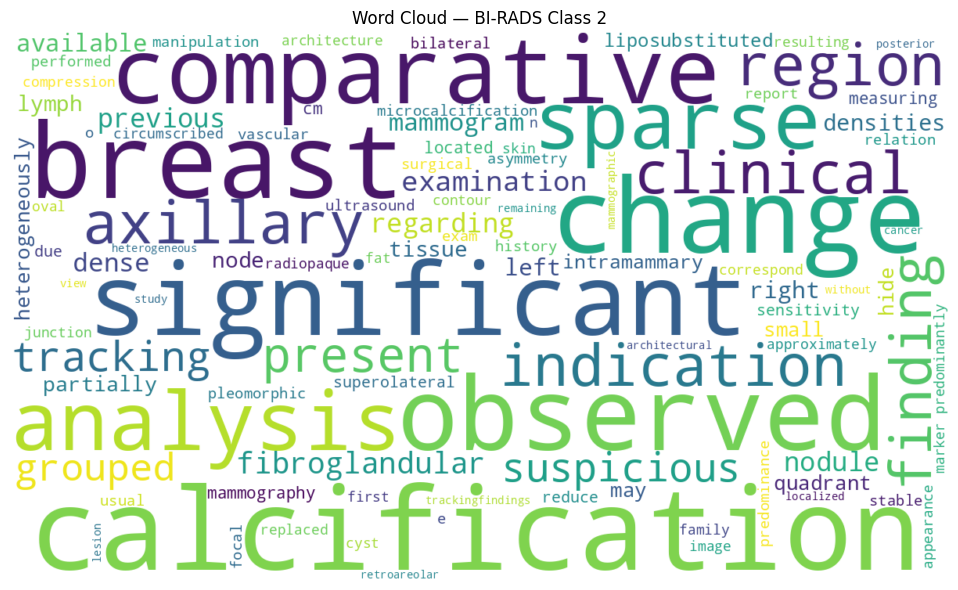

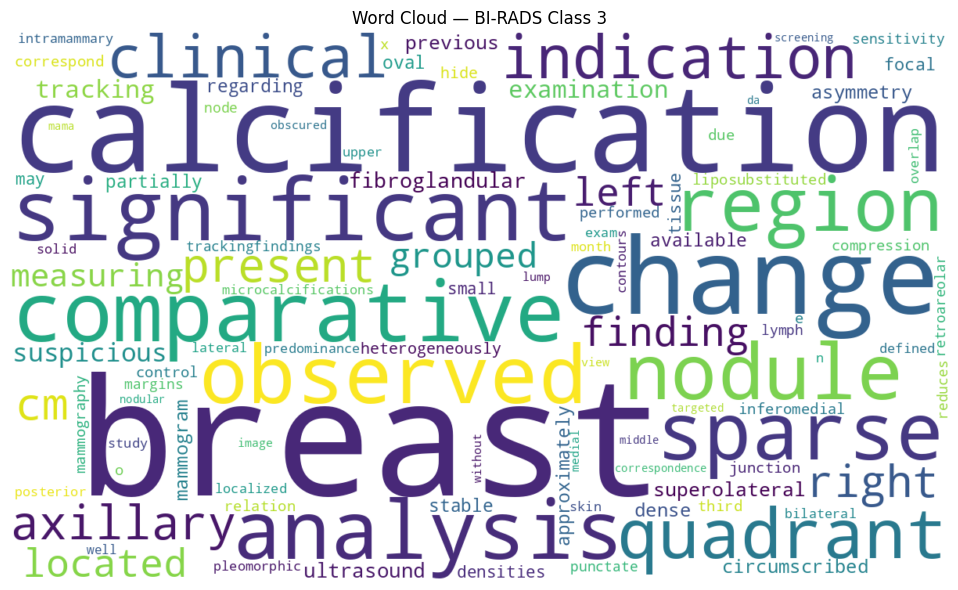

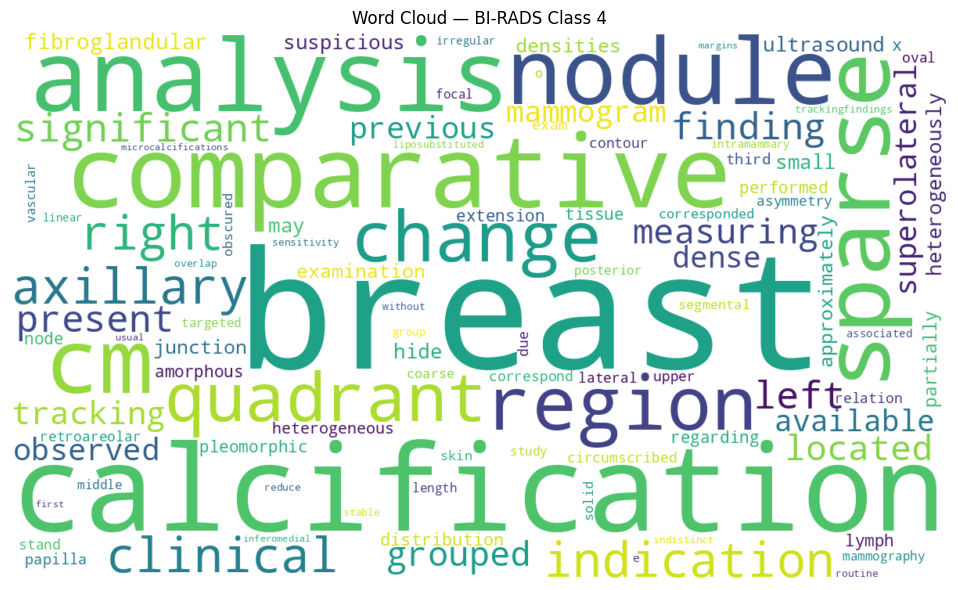

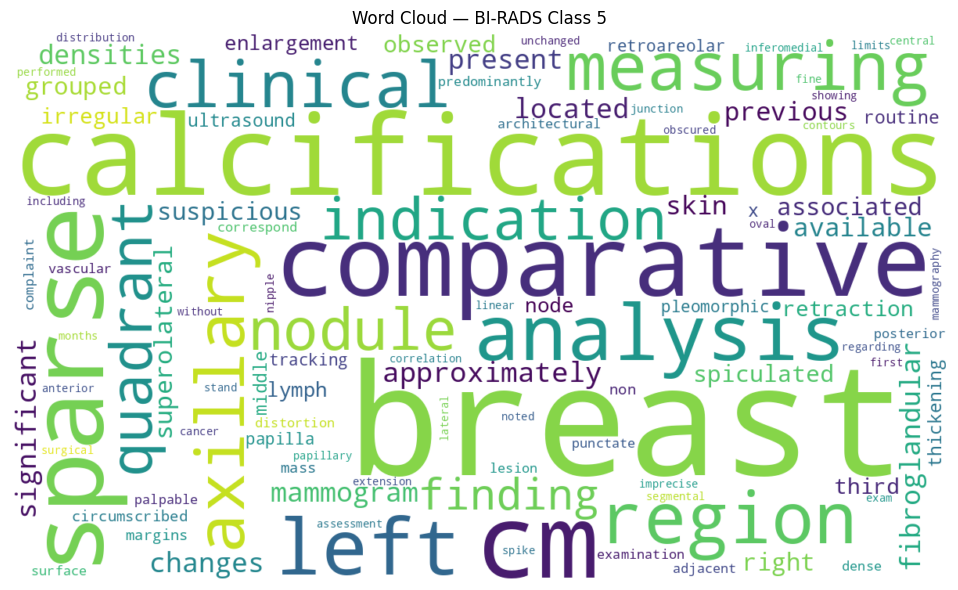

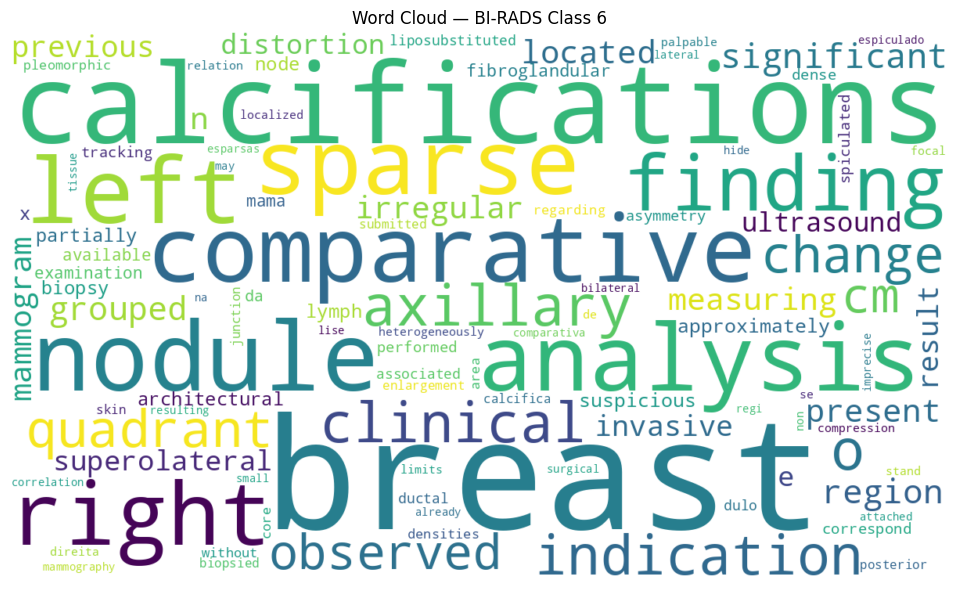

In [33]:
# ============================================================
# CLASS-SPECIFIC WORD CLOUDS
# ============================================================

for label in classes:

    class_text = ' '.join(
        train_df[
            train_df[LABEL_COLUMN] == label
        ][TEXT_COLUMN]
        .fillna('')
        .astype(str)
    )

    if not class_text.strip():
        print(f"No text available for class {label}")
        continue

    wc = WordCloud(
        width=1200,
        height=700,
        background_color='white',
        max_words=100,
        collocations=False
    ).generate(class_text)

    plt.figure(figsize=(12, 6))

    plt.imshow(
        wc,
        interpolation='bilinear'
    )

    plt.axis('off')

    plt.title(
        f'Word Cloud — BI-RADS Class {label}'
    )

    plt.tight_layout()

    filename = (
        f'wordcloud_birads_{str(label).replace("/", "_")}.png'
    )

    plt.savefig(
        os.path.join(
            FIGURE_DIR,
            filename
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [34]:
# ============================================================
# LOAD SAVED BEST MODEL + VECTORIZER
# ============================================================

best_model_path = os.path.join(
    MODEL_DIR,
    f'{BEST_FEATURE_TYPE}__{BEST_MODEL_NAME}.pkl'
)

best_vectorizer_path = os.path.join(
    VECTORIZER_DIR,
    f'{BEST_FEATURE_TYPE}_vectorizer.pkl'
)

if not os.path.exists(best_model_path):
    raise FileNotFoundError(best_model_path)

if not os.path.exists(best_vectorizer_path):
    raise FileNotFoundError(best_vectorizer_path)

best_model = joblib.load(best_model_path)
best_vectorizer = joblib.load(best_vectorizer_path)

feature_names = np.array(
    best_vectorizer.get_feature_names_out()
)

print("Loaded:")
print("Model:", best_model_path)
print("Vectorizer:", best_vectorizer_path)
print("Number of features:", len(feature_names))

Loaded:
Model: /content/mydrive/MyDrive/NLP_Research_Project/results/models/classical_ml/trained_models/tfidf__linear_svm.pkl
Vectorizer: /content/mydrive/MyDrive/NLP_Research_Project/results/models/classical_ml/vectorizers/tfidf_vectorizer.pkl
Number of features: 15494


In [35]:
# ============================================================
# FEATURE IMPORTANCE EXTRACTION
# ============================================================

def get_linear_feature_importance(model, feature_names, classes):
    """
    Extract discriminative features from linear models such as
    Logistic Regression and Linear SVM.
    """

    coef = model.coef_

    results = {}

    for i, class_label in enumerate(classes):

        scores = coef[i]

        top_positive = np.argsort(scores)[::-1][:20]
        top_negative = np.argsort(scores)[:20]

        results[class_label] = {
            'positive_features': feature_names[top_positive],
            'positive_scores': scores[top_positive],
            'negative_features': feature_names[top_negative],
            'negative_scores': scores[top_negative]
        }

    return results

In [38]:
# ============================================================
# FEATURE IMPORTANCE EXTRACTION
# ============================================================
# ============================================================
# LINEAR MODEL EXPLAINABILITY
# ============================================================

if BEST_MODEL_NAME in ['logistic_regression', 'linear_svm']:

    feature_results = get_linear_feature_importance(
        best_model,
        feature_names,
        classes
    )

    feature_rows = []

    for class_label, result in feature_results.items():

        for feature, score in zip(
            result['positive_features'],
            result['positive_scores']
        ):

            feature_rows.append({
                'class': class_label,
                'feature': feature,
                'coefficient': score,
                'direction': 'positive'
            })

        for feature, score in zip(
            result['negative_features'],
            result['negative_scores']
        ):

            feature_rows.append({
                'class': class_label,
                'feature': feature,
                'coefficient': score,
                'direction': 'negative'
            })

    feature_importance_df = pd.DataFrame(feature_rows)

    display(feature_importance_df.head(40))

    feature_importance_df.to_csv(
        os.path.join(
            EXPLAINABILITY_DIR,
            f'{BEST_MODEL_NAME}_top_features.csv'
        ),
        index=False
    )

else:

    print(
        f"Best model is {BEST_MODEL_NAME}. "
        "Linear coefficient analysis is not applicable."
    )

def get_linear_feature_importance(model, feature_names, classes):
    """
    Extract discriminative features from linear models such as
    Logistic Regression and Linear SVM.
    """

    coef = model.coef_

    results = {}

    for i, class_label in enumerate(classes):

        scores = coef[i]

        top_positive = np.argsort(scores)[::-1][:20]
        top_negative = np.argsort(scores)[:20]

        results[class_label] = {
            'positive_features': feature_names[top_positive],
            'positive_scores': scores[top_positive],
            'negative_features': feature_names[top_negative],
            'negative_scores': scores[top_negative]
        }

    return results

,class,feature,coefficient,direction
0,0,breast sparse,1.977565,positive
1,0,cm the,1.943964,positive
2,0,obscured,1.881258,positive
3,0,focal,1.738156,positive
4,0,quadrant sparse,1.436454,positive
5,0,cm intramammary,1.431468,positive
6,0,focal asymmetry,1.343329,positive
7,0,retroareolar,1.342548,positive
8,0,observed sparse,1.295092,positive
9,0,breast retroareolar,1.242623,positive


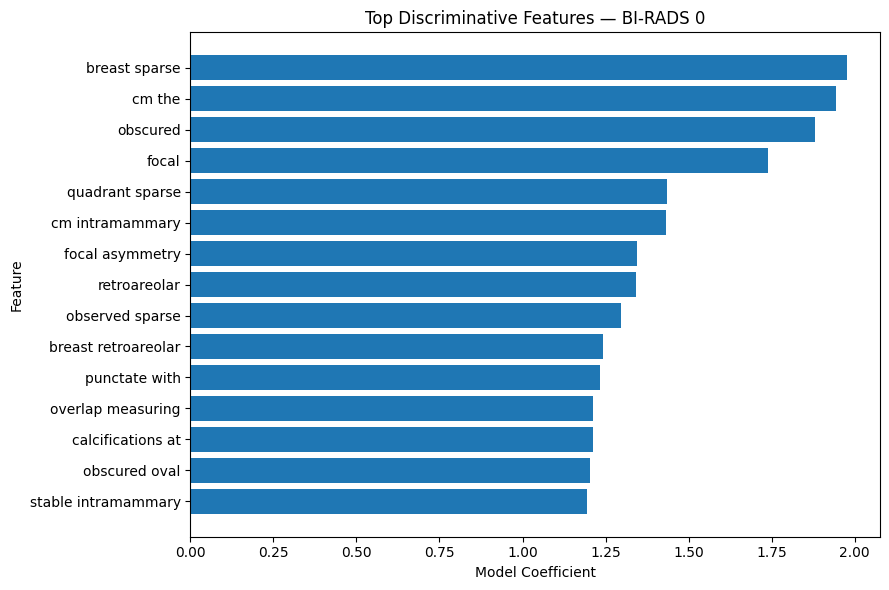

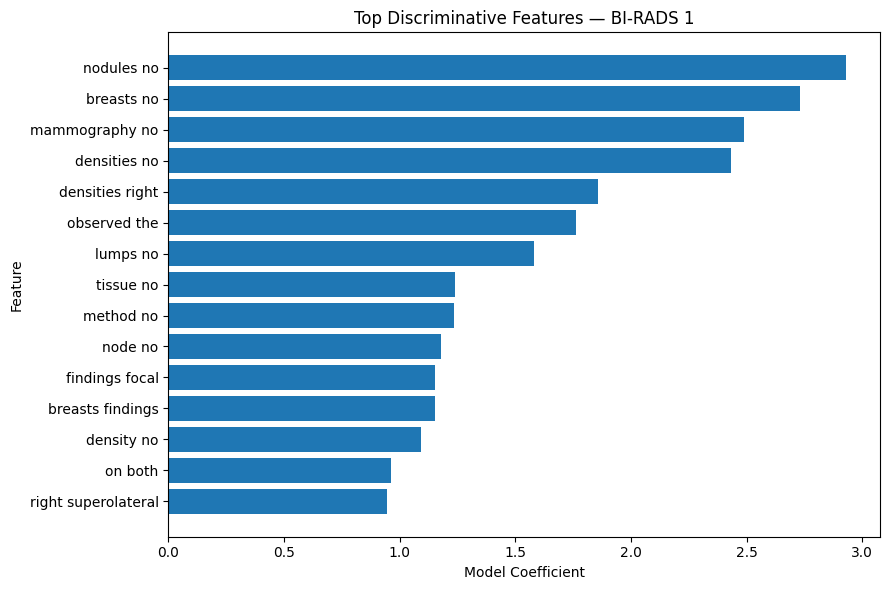

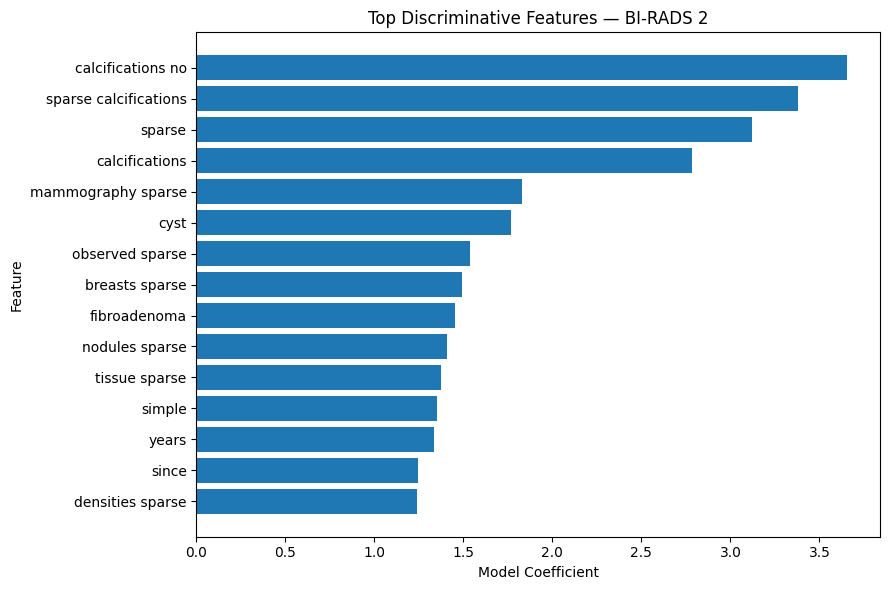

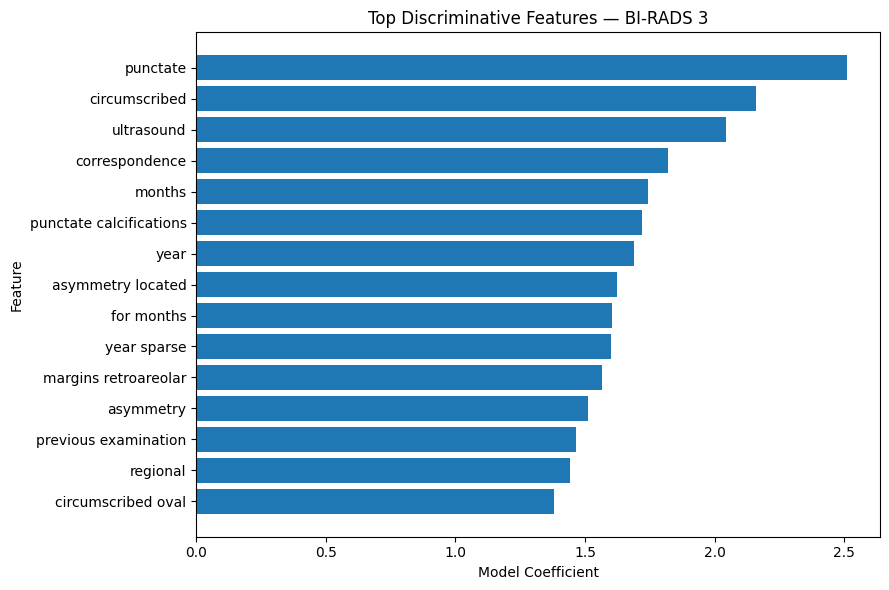

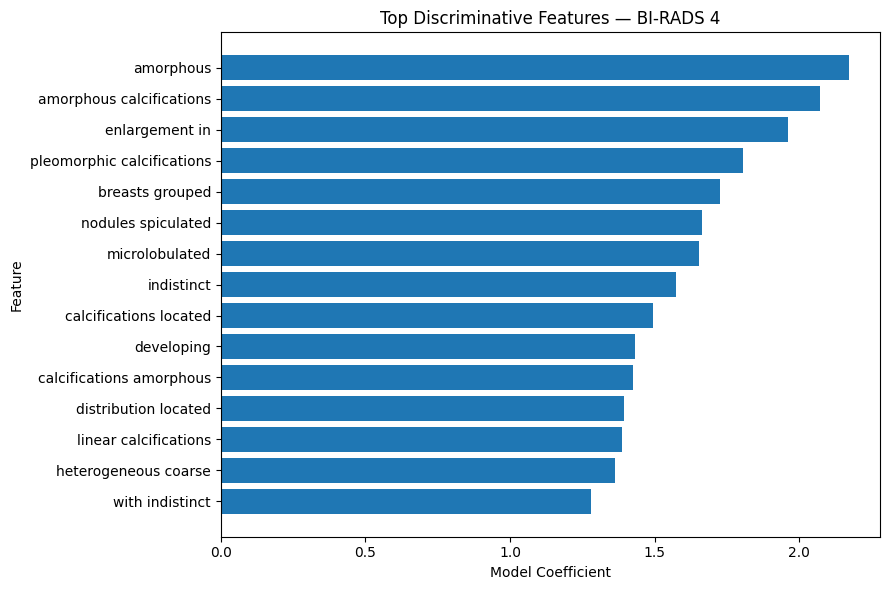

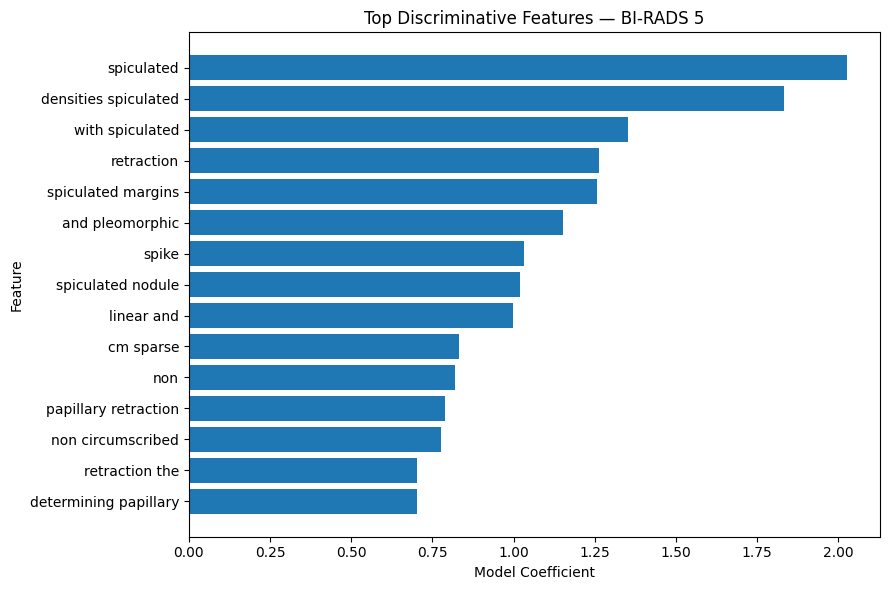

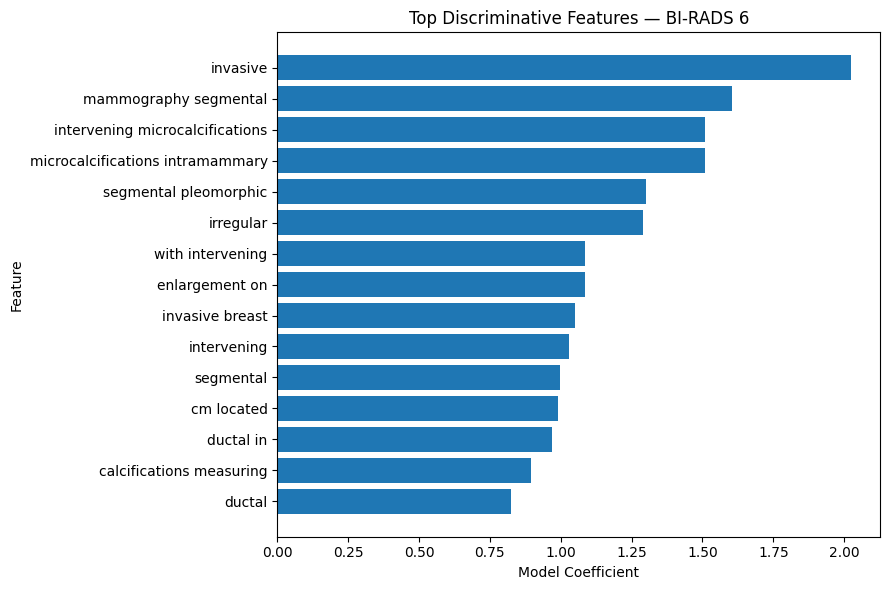

In [39]:
# ============================================================
# TOP DISCRIMINATIVE FEATURES
# ============================================================

if BEST_MODEL_NAME in ['logistic_regression', 'linear_svm']:

    for class_label in classes:

        class_data = feature_importance_df[
            (feature_importance_df['class'] == class_label) &
            (feature_importance_df['direction'] == 'positive')
        ].sort_values(
            'coefficient',
            ascending=True
        ).tail(15)

        plt.figure(figsize=(9, 6))

        plt.barh(
            class_data['feature'],
            class_data['coefficient']
        )

        plt.xlabel('Model Coefficient')
        plt.ylabel('Feature')
        plt.title(
            f'Top Discriminative Features — BI-RADS {class_label}'
        )

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                FIGURE_DIR,
                f'top_features_class_{class_label}.png'
            ),
            dpi=300,
            bbox_inches='tight'
        )

        plt.show()

In [40]:
# ============================================================
# GENERATE TEST SCORES FROM SAVED MODEL
# ============================================================

X_test_best = best_vectorizer.transform(
    test_df[TEXT_COLUMN].fillna('')
)

if hasattr(best_model, 'predict_proba'):

    test_scores = best_model.predict_proba(
        X_test_best
    )

    score_type = 'probability'

elif hasattr(best_model, 'decision_function'):

    test_scores = best_model.decision_function(
        X_test_best
    )

    score_type = 'decision_score'

else:

    test_scores = None
    score_type = None

print("Score type:", score_type)

Score type: decision_score


In [41]:
# ============================================================
# MULTICLASS ROC-AUC
# ============================================================

if test_scores is not None:

    y_test_binary = label_binarize(
        y_true,
        classes=classes
    )

    if test_scores.ndim == 1:
        test_scores_for_auc = np.column_stack(
            [-test_scores, test_scores]
        )
    else:
        test_scores_for_auc = test_scores

    roc_auc_macro = roc_auc_score(
        y_test_binary,
        test_scores_for_auc,
        average='macro',
        multi_class='ovr'
    )

    roc_auc_weighted = roc_auc_score(
        y_test_binary,
        test_scores_for_auc,
        average='weighted',
        multi_class='ovr'
    )

    print("Macro ROC-AUC:", round(roc_auc_macro, 4))
    print("Weighted ROC-AUC:", round(roc_auc_weighted, 4))

else:

    print(
        "ROC-AUC cannot be computed because "
        "the selected model does not expose usable scores."
    )

Macro ROC-AUC: 0.9783
Weighted ROC-AUC: 0.9703


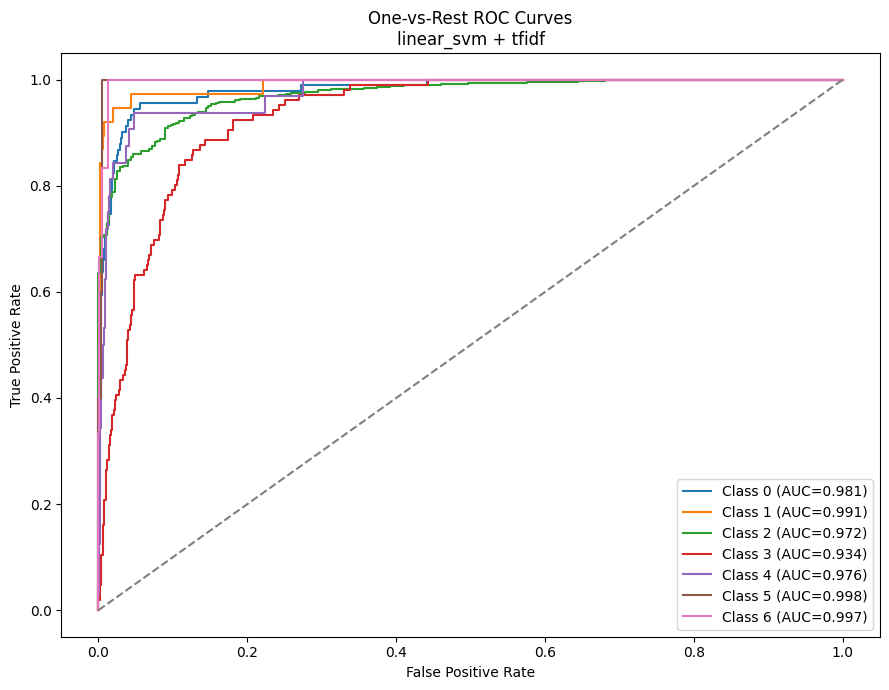

In [42]:
# ============================================================
# ONE-vs-REST ROC CURVES
# ============================================================

if test_scores is not None:

    plt.figure(figsize=(9, 7))

    for i, label in enumerate(classes):

        fpr, tpr, _ = roc_curve(
            y_test_binary[:, i],
            test_scores_for_auc[:, i]
        )

        class_auc = auc(fpr, tpr)

        plt.plot(
            fpr,
            tpr,
            label=f'Class {label} (AUC={class_auc:.3f})'
        )

    plt.plot(
        [0, 1],
        [0, 1],
        linestyle='--'
    )

    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')

    plt.title(
        f'One-vs-Rest ROC Curves\n'
        f'{BEST_MODEL_NAME} + {BEST_FEATURE_TYPE}'
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURE_DIR,
            'best_model_multiclass_roc.png'
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

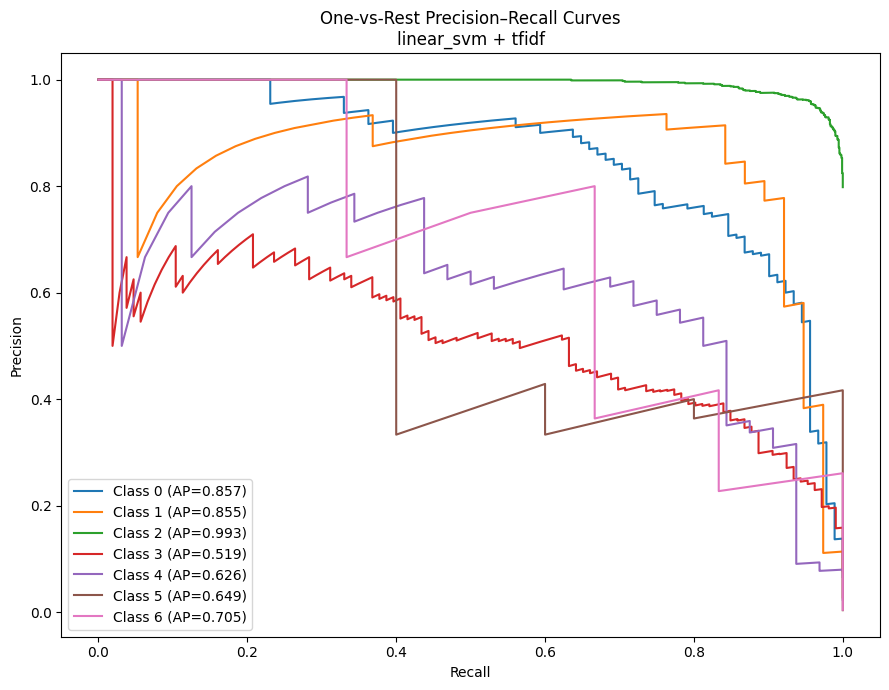

,class,average_precision
0,0,0.857455
1,1,0.854916
2,2,0.992752
3,3,0.518644
4,4,0.625704
5,5,0.649048
6,6,0.704589


In [43]:
# ============================================================
# PRECISION-RECALL CURVES
# ============================================================

if test_scores is not None:

    plt.figure(figsize=(9, 7))

    ap_rows = []

    for i, label in enumerate(classes):

        precision, recall, _ = precision_recall_curve(
            y_test_binary[:, i],
            test_scores_for_auc[:, i]
        )

        ap = average_precision_score(
            y_test_binary[:, i],
            test_scores_for_auc[:, i]
        )

        ap_rows.append({
            'class': label,
            'average_precision': ap
        })

        plt.plot(
            recall,
            precision,
            label=f'Class {label} (AP={ap:.3f})'
        )

    plt.xlabel('Recall')
    plt.ylabel('Precision')

    plt.title(
        f'One-vs-Rest Precision–Recall Curves\n'
        f'{BEST_MODEL_NAME} + {BEST_FEATURE_TYPE}'
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURE_DIR,
            'best_model_precision_recall.png'
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

    ap_df = pd.DataFrame(ap_rows)

    display(ap_df)

    ap_df.to_csv(
        os.path.join(
            ADVANCED_METRICS_DIR,
            'best_model_average_precision.csv'
        ),
        index=False
    )

In [44]:
# ============================================================
# PREDICTION CONFIDENCE ANALYSIS
# ============================================================

if hasattr(best_model, 'predict_proba'):

    probabilities = best_model.predict_proba(
        X_test_best
    )

    confidence = probabilities.max(axis=1)

    confidence_df = pd.DataFrame({
        ID_COLUMN: test_df[ID_COLUMN],
        'true_label': y_true.values,
        'predicted_label': y_pred.values,
        'confidence': confidence
    })

    confidence_df['correct'] = (
        confidence_df['true_label'] ==
        confidence_df['predicted_label']
    )

    display(confidence_df.head())

else:

    confidence_df = None

    print(
        "Probability-based confidence analysis "
        "is unavailable for this model."
    )

Probability-based confidence analysis is unavailable for this model.


In [45]:
# ============================================================
# CONFIDENCE DISTRIBUTION
# ============================================================

if confidence_df is not None:

    plt.figure(figsize=(9, 6))

    plt.hist(
        confidence_df.loc[
            confidence_df['correct'],
            'confidence'
        ],
        bins=20,
        alpha=0.7,
        label='Correct'
    )

    plt.hist(
        confidence_df.loc[
            ~confidence_df['correct'],
            'confidence'
        ],
        bins=20,
        alpha=0.7,
        label='Incorrect'
    )

    plt.xlabel('Prediction Confidence')
    plt.ylabel('Number of Samples')

    plt.title(
        'Prediction Confidence Distribution'
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        os.path.join(
            FIGURE_DIR,
            'prediction_confidence_distribution.png'
        ),
        dpi=300,
        bbox_inches='tight'
    )

    plt.show()

In [47]:
# ============================================================
# HIGH-CONFIDENCE ERRORS
# ============================================================

if confidence_df is not None:

    high_confidence_errors = (
        confidence_df[
            ~confidence_df['correct']
        ]
        .sort_values(
            'confidence',
            ascending=False
        )
    )

    display(
        high_confidence_errors.head(20)
    )

    high_confidence_errors.to_csv(
        os.path.join(
            ERROR_DIR,
            'high_confidence_errors.csv'
        ),
        index=False
    )

In [48]:
# ============================================================
# DISCRIMINATIVE UNIGRAM / BIGRAM ANALYSIS
# ============================================================

if BEST_MODEL_NAME in [
    'logistic_regression',
    'linear_svm'
]:

    feature_importance_df['feature_type'] = (
        feature_importance_df['feature']
        .apply(
            lambda x: 'bigram' if ' ' in str(x)
            else 'unigram'
        )
    )

    ngram_summary = (
        feature_importance_df
        .groupby('feature_type')
        .size()
        .reset_index(name='count')
    )

    display(ngram_summary)

    feature_importance_df.to_csv(
        os.path.join(
            EXPLAINABILITY_DIR,
            'discriminative_unigram_bigram_analysis.csv'
        ),
        index=False
    )

,feature_type,count
0,bigram,172
1,unigram,108


In [49]:
# ============================================================
# ADVANCED EVALUATION SUMMARY
# ============================================================

advanced_summary = {
    'best_feature_type': BEST_FEATURE_TYPE,
    'best_model': BEST_MODEL_NAME,
    'validation_macro_f1': best_row['val_f1_macro'],
    'test_accuracy': best_row['test_accuracy'],
    'test_macro_f1': best_row['test_f1_macro'],
    'test_weighted_f1': best_row['test_f1_weighted'],
}

if test_scores is not None:

    advanced_summary['macro_roc_auc'] = roc_auc_macro
    advanced_summary['weighted_roc_auc'] = roc_auc_weighted

advanced_summary_df = pd.DataFrame(
    [advanced_summary]
)

display(advanced_summary_df)

advanced_summary_df.to_csv(
    os.path.join(
        ADVANCED_METRICS_DIR,
        'advanced_ml_evaluation_summary.csv'
    ),
    index=False
)

,best_feature_type,best_model,validation_macro_f1,test_accuracy,test_macro_f1,test_weighted_f1,macro_roc_auc,weighted_roc_auc
0,tfidf,linear_svm,0.737544,0.896877,0.695597,0.899857,0.978317,0.970266


In [50]:
# ============================================================
# FINAL OUTPUT INVENTORY
# ============================================================

print("=" * 65)
print("ML ADVANCED EVALUATION COMPLETE")
print("=" * 65)

print("\nExisting artifacts reused:")
print("✓ Trained models")
print("✓ Fitted vectorizers")
print("✓ Validation predictions")
print("✓ Test predictions")
print("✓ Existing metrics")

print("\nNew outputs generated by this notebook:")

print("✓ Per-class test metrics")
print("✓ Test normalized confusion matrix")
print("✓ Misclassification pair analysis")
print("✓ Misclassified report analysis")
print("✓ Word clouds")
print("✓ Class-specific word clouds")
print("✓ Model feature explainability")
print("✓ Discriminative n-gram analysis")
print("✓ ROC-AUC analysis")
print("✓ ROC curves")
print("✓ Precision-Recall curves")
print("✓ Average Precision")
print("✓ Prediction confidence analysis")
print("✓ High-confidence error analysis")

print("\nOutput directories:")
print("Figures:", FIGURE_DIR)
print("Explainability:", EXPLAINABILITY_DIR)
print("Error analysis:", ERROR_DIR)
print("Advanced metrics:", ADVANCED_METRICS_DIR)

ML ADVANCED EVALUATION COMPLETE

Existing artifacts reused:
✓ Trained models
✓ Fitted vectorizers
✓ Validation predictions
✓ Test predictions
✓ Existing metrics

New outputs generated by this notebook:
✓ Per-class test metrics
✓ Test normalized confusion matrix
✓ Misclassification pair analysis
✓ Misclassified report analysis
✓ Word clouds
✓ Class-specific word clouds
✓ Model feature explainability
✓ Discriminative n-gram analysis
✓ ROC-AUC analysis
✓ ROC curves
✓ Precision-Recall curves
✓ Average Precision
✓ Prediction confidence analysis
✓ High-confidence error analysis

Output directories:
Figures: /content/mydrive/MyDrive/NLP_Research_Project/results/figures/classical_ml_evaluation
Explainability: /content/mydrive/MyDrive/NLP_Research_Project/results/explainability/classical_ml
Error analysis: /content/mydrive/MyDrive/NLP_Research_Project/results/error_analysis/classical_ml
Advanced metrics: /content/mydrive/MyDrive/NLP_Research_Project/results/advanced_metrics/classical_ml
